# Sprint -2 Measures of Dispersion 

**1. Range**

**Concept Explanation**
Range is the simplest measure of spread. It just tells you the gap between the biggest and smallest value in a dataset.

**Formula**
Range = Maximum value − Minimum value

**Real-world Example**
The daily temperature range in a city, say the highest was 38°C and the lowest was 22°C, gives a range of 16°C.

**Business Example**
An HR team looks at the range of salaries in a department to understand the pay gap between the lowest and highest paid employee.

**AI/ML Example**
Range is checked during data exploration to spot the scale of a feature before deciding whether to normalize or scale it for a model.

**Numerical Example**
Daily sales for a week: 120, 150, 90, 200, 175, 160, 130
Range = 200 − 90 = 110

**Interpretation of Results**
A range of 110 tells you sales swing quite a bit during the week, but it does not tell you anything about the values in between.

**Advantages**
Very easy to calculate and understand. Gives a quick first look at spread.

**Limitations**
Only uses two values, the max and the min, so it ignores everything else and gets thrown off badly by a single outlier.




In [34]:
import numpy as np
import pandas as pd

sales = [120, 150, 90, 200, 175, 160, 130]
data = pd.Series(sales)

range_value = data.max() - data.min()
print("Max:", data.max())
print("Min:", data.min())
print("Range:", range_value)

Max: 200
Min: 90
Range: 110


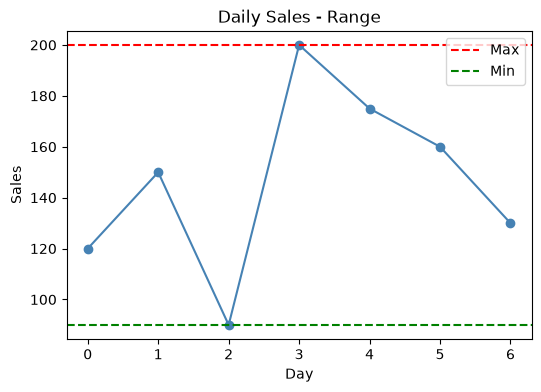

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(sales, marker="o", color="steelblue")
plt.axhline(data.max(), color="red", linestyle="--", label="Max")
plt.axhline(data.min(), color="green", linestyle="--", label="Min")
plt.title("Daily Sales - Range")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.legend()
plt.show()

**2. Variance**

**Concept Explanation**
Variance measures how far each value in a dataset is from the mean, on average, using squared differences. A bigger variance means the data is more spread out.

**Formula**
Sample Variance: s² = (sum of (x − mean)²) / (n − 1)
Population Variance: σ² = (sum of (x − mean)²) / N

**Real-world Example**
Two students both average 70 marks across tests, but one student's marks vary between 60-80 while the other varies between 40-100. The second student has a much higher variance.

**Business Example**
A logistics company checks the variance in delivery times across routes to see which routes are unpredictable versus consistent.

**AI/ML Example**
Variance is used in feature selection, since features with very low variance carry little useful information and are sometimes dropped before training a model.

**Numerical Example**
Test scores: 60, 70, 80
Mean = 70
Squared differences: (60-70)²=100, (70-70)²=0, (80-70)²=100
Sample variance = (100+0+100) / (3-1) = 200/2 = 100

**Interpretation of Results**
A variance of 100 means scores are fairly spread out around the mean of 70. If variance were closer to 0, all scores would be nearly identical.

**Advantages**
Uses every data point, not just the extremes, so it reflects the full spread of the dataset.

**Limitations**
The result is in squared units, which is hard to interpret directly, and it is sensitive to outliers since differences are squared.



In [36]:
import numpy as np
import pandas as pd

scores = [60, 70, 80]
data = pd.Series(scores)

print("Sample Variance:", data.var())
print("Population Variance:", data.var(ddof=0))

Sample Variance: 100.0
Population Variance: 66.66666666666667


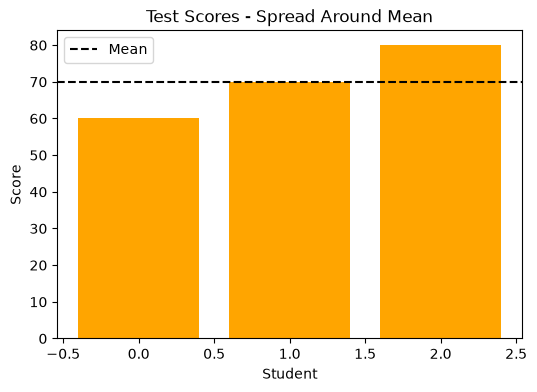

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(range(len(scores)), scores, color="orange")
plt.axhline(data.mean(), color="black", linestyle="--", label="Mean")
plt.title("Test Scores - Spread Around Mean")
plt.xlabel("Student")
plt.ylabel("Score")
plt.legend()
plt.show()

**3. Standard Deviation**

**Concept Explanation**
Standard deviation is the square root of variance. It brings the spread measure back into the original units of the data, making it easier to interpret than variance.

**Formula**
Sample Standard Deviation: s = √(sum of (x − mean)² / (n − 1))
Population Standard Deviation: σ = √(sum of (x − mean)² / N)

**Real-world Example**
If the average height in a class is 160 cm with a standard deviation of 5 cm, most students' heights fall roughly between 155 and 165 cm.

**Business Example**
A quality control team measures the standard deviation of product weights coming off a production line to check consistency, a low standard deviation means the process is stable.

**AI/ML Example**
Standard deviation is used in feature scaling, specifically in standardization, where each feature is transformed to have a mean of 0 and standard deviation of 1 so all features are on the same scale.

**Numerical Example**
Using the same test scores: 60, 70, 80
Variance was 100, so Standard Deviation = √100 = 10

**Interpretation of Results**
A standard deviation of 10 means scores typically differ from the mean of 70 by about 10 points, so most scores fall roughly between 60 and 80.

**Advantages**
Same units as the original data, so it is much easier to interpret than variance, and it is widely used across statistics and ML.

**Limitations**
Still sensitive to outliers since it is built on variance, and it assumes the data is reasonably symmetric to be most meaningful.



In [38]:
import numpy as np
import pandas as pd

scores = [60, 70, 80]
data = pd.Series(scores)

print("Sample Standard Deviation:", data.std())
print("Population Standard Deviation:", data.std(ddof=0))

Sample Standard Deviation: 10.0
Population Standard Deviation: 8.16496580927726


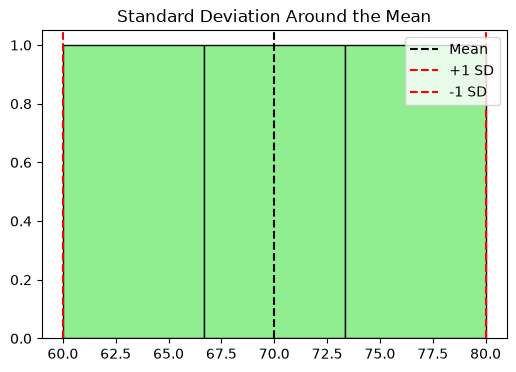

In [39]:
import matplotlib.pyplot as plt
import numpy as np

mean = data.mean()
std = data.std()

plt.figure(figsize=(6,4))
plt.hist(scores, bins=3, color="lightgreen", edgecolor="black")
plt.axvline(mean, color="black", linestyle="--", label="Mean")
plt.axvline(mean+std, color="red", linestyle="--", label="+1 SD")
plt.axvline(mean-std, color="red", linestyle="--", label="-1 SD")
plt.title("Standard Deviation Around the Mean")
plt.legend()
plt.show()

**4. Quartiles**

**Concept Explanation**
Quartiles split an ordered dataset into four equal parts. Q1 is the value below which 25 percent of the data falls, Q2 is the median, and Q3 is the value below which 75 percent of the data falls.

**Formula**
Q1 = value at the 25th percentile position
Q2 = value at the 50th percentile position, which is the median
Q3 = value at the 75th percentile position

**Real-world Example**
In a marathon, if your finish time falls in the first quartile, it means you finished faster than 75 percent of the runners.

**Business Example**
A company divides its salespeople into quartiles based on revenue generated, to identify top performers in Q4 and those who need support in Q1.

**AI/ML Example**
Quartiles are used to detect outliers before training a model, values far outside Q1 and Q3 are often flagged for review or removal.

**Numerical Example**
Dataset: 10, 20, 30, 40, 50, 60, 70, 80
Q1 = 27.5, Q2 (median) = 45, Q3 = 62.5

**Interpretation of Results**
25 percent of the values fall below 27.5, half fall below 45, and 75 percent fall below 62.5, giving a clear picture of how the data is distributed across four parts.

**Advantages**
Gives more detail about the shape of the data than a single average, and is not affected by extreme outliers as much as the mean.

**Limitations**
Different software or methods can calculate quartiles slightly differently, and quartiles alone do not show the exact shape of the distribution.



In [40]:
import numpy as np

data = [10, 20, 30, 40, 50, 60, 70, 80]

q1 = np.percentile(data, 25)
q2 = np.percentile(data, 50)
q3 = np.percentile(data, 75)

print("Q1:", q1)
print("Q2 (Median):", q2)
print("Q3:", q3)

Q1: 27.5
Q2 (Median): 45.0
Q3: 62.5


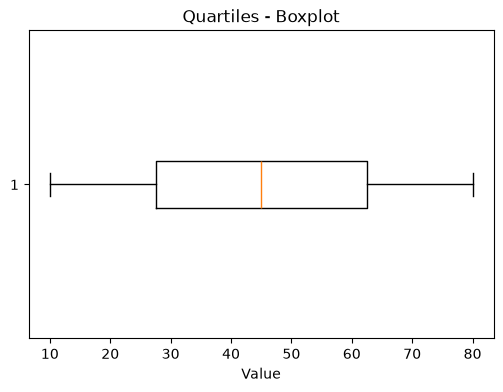

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(data, orientation="horizontal")
plt.title("Quartiles - Boxplot")
plt.xlabel("Value")
plt.show()

**5. Percentiles**

**Concept Explanation**
A percentile tells you the value below which a certain percentage of the data falls. For example, the 90th percentile is the value below which 90 percent of the data lies.

**Formula**
Position of pth percentile = (p / 100) × (n + 1)
Then interpolate between the surrounding data points if needed.

**Real-world Example**
If a baby's weight is in the 60th percentile on a growth chart, it means the baby weighs more than 60 percent of babies of the same age.

**Business Example**
An e-commerce company looks at the 95th percentile of page load time to understand the experience of their slowest users, not just the average user.

**AI/ML Example**
Percentiles are used to cap or clip extreme values during preprocessing, a technique called winsorizing, where values above the 99th percentile are capped to reduce the effect of outliers.

**Numerical Example**
Dataset: 15, 20, 35, 40, 50
The 40th percentile position ≈ 40/100 × (5+1) = 2.4, so it falls between the 2nd (20) and 3rd (35) values, interpolated to about 26.

**Interpretation of Results**
The 40th percentile value of about 26 means 40 percent of the data falls below this point.

**Advantages**
Gives a very flexible way to describe any position within the data, more detailed than quartiles.

**Limitations**
Can be confusing to interpret for people unfamiliar with statistics, and different interpolation methods can give slightly different results.



In [42]:
import numpy as np

data = [15, 20, 35, 40, 50]

p40 = np.percentile(data, 40)
p90 = np.percentile(data, 90)

print("40th Percentile:", p40)
print("90th Percentile:", p90)

40th Percentile: 29.0
90th Percentile: 46.0


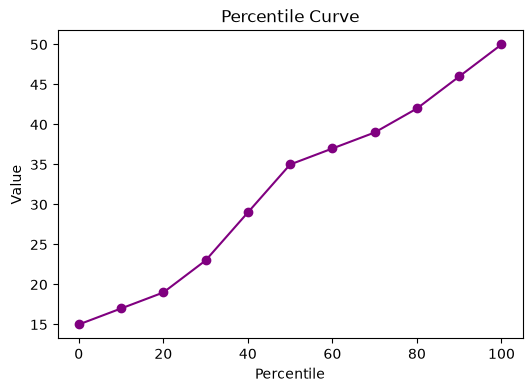

In [43]:
import matplotlib.pyplot as plt
import numpy as np

sorted_data = np.sort(data)
percentiles = [np.percentile(data, p) for p in range(0, 101, 10)]

plt.figure(figsize=(6,4))
plt.plot(range(0, 101, 10), percentiles, marker="o", color="purple")
plt.title("Percentile Curve")
plt.xlabel("Percentile")
plt.ylabel("Value")
plt.show()

**6. Interquartile Range (IQR)**

**Concept Explanation**
IQR measures the spread of the middle 50 percent of the data, calculated as the difference between Q3 and Q1. It ignores the extreme top and bottom 25 percent, making it a robust measure of spread.

**Formula**
IQR = Q3 − Q1

**Real-world Example**
When comparing household incomes in a neighborhood, IQR shows how spread out the middle-income households are, without being distorted by a few very rich or very poor households.

**Business Example**
A retailer analyzes the IQR of order values to understand typical customer spending, without extreme bulk orders or very small orders skewing the picture.

**AI/ML Example**
IQR is commonly used to detect and remove outliers before training a model, any value below Q1 minus 1.5×IQR or above Q3 plus 1.5×IQR is flagged as an outlier.

**Numerical Example**
Using the earlier dataset: 10, 20, 30, 40, 50, 60, 70, 80
Q1 = 27.5, Q3 = 62.5
IQR = 62.5 − 27.5 = 35

**Interpretation of Results**
An IQR of 35 tells you the middle 50 percent of the data spans a range of 35 units, giving a sense of spread without extreme values pulling the number around.

**Advantages**
Not affected by outliers, since it focuses only on the middle half of the data, making it more reliable than range for skewed data.

**Limitations**
Ignores the tails of the distribution completely, so it can miss important information about extreme values that might matter for the analysis.



In [44]:
import numpy as np

data = [10, 20, 30, 40, 50, 60, 70, 80]

q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1, "Q3:", q3)
print("IQR:", iqr)
print("Outlier bounds:", lower_bound, "to", upper_bound)

Q1: 27.5 Q3: 62.5
IQR: 35.0
Outlier bounds: -25.0 to 115.0


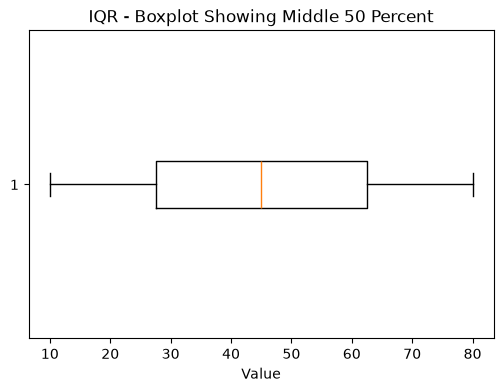

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(data, orientation="horizontal")
plt.title("IQR - Boxplot Showing Middle 50 Percent")
plt.xlabel("Value")
plt.show()

**7. Coefficient of Variation**

**Concept Explanation**
Coefficient of Variation, or CV, expresses standard deviation as a percentage of the mean. It is used to compare the relative spread of two datasets that have different units or very different scales.

**Formula**
CV = (Standard Deviation / Mean) × 100

**Real-world Example**
Comparing the variability of a city's daily temperature (measured in degrees) with its daily rainfall (measured in millimeters) only makes sense using CV, since standard deviation alone cannot be compared across different units.

**Business Example**
An investor compares the CV of two stocks' returns to judge which one is riskier relative to its own average return, even if the stocks are priced very differently.

**AI/ML Example**
CV is used during feature exploration to compare the relative variability of different numeric features that are on different scales, like age versus income, before deciding on preprocessing steps.

**Numerical Example**
Stock A: Mean return = 10 percent, Standard Deviation = 2 percent → CV = (2/10) × 100 = 20 percent
Stock B: Mean return = 20 percent, Standard Deviation = 3 percent → CV = (3/20) × 100 = 15 percent
Even though Stock B has a higher standard deviation, its CV is lower, meaning it is relatively less risky per unit of return.

**Interpretation of Results**
A lower CV means more consistency relative to the mean, so Stock B, despite having larger absolute swings, is actually the more stable option relative to its own average return.

**Advantages**
Allows fair comparison of variability between datasets with different units or very different means, which standard deviation alone cannot do.

**Limitations**
Not meaningful when the mean is close to zero or negative, since dividing by a very small or negative number distorts the result.



In [46]:
import numpy as np

stock_a = {"mean": 10, "std": 2}
stock_b = {"mean": 20, "std": 3}

cv_a = (stock_a["std"] / stock_a["mean"]) * 100
cv_b = (stock_b["std"] / stock_b["mean"]) * 100

print("Stock A CV:", round(cv_a, 2), "%")
print("Stock B CV:", round(cv_b, 2), "%")

Stock A CV: 20.0 %
Stock B CV: 15.0 %


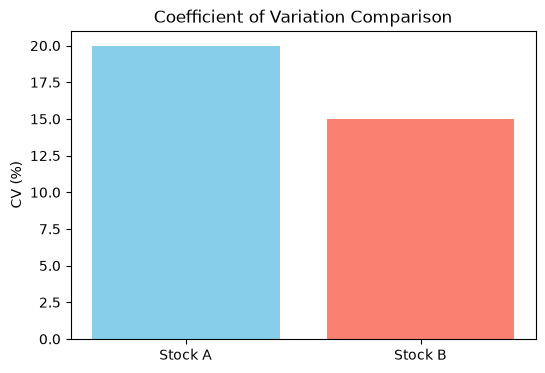

In [48]:
import matplotlib.pyplot as plt

stocks = ["Stock A", "Stock B"]
cv_values = [cv_a, cv_b]

plt.figure(figsize=(6,4))
plt.bar(stocks, cv_values, color=["skyblue", "salmon"])
plt.title("Coefficient of Variation Comparison")
plt.ylabel("CV (%)")
plt.show()

**Minimum 5 Interview Questions with Answers**

Q1. What is dispersion in statistics, and why does it matter alongside the mean?
Dispersion tells you how spread out the data is. Two datasets can have the same mean but look completely different, one tightly packed and one all over the place, and dispersion is what catches that difference.

Q2. What's the difference between range, variance, and standard deviation?
Range only looks at the highest and lowest value. Variance looks at how far every value is from the mean, using squared differences. Standard deviation is just the square root of variance, brought back into the original units so it's easier to read.

Q3. Why would you use IQR instead of standard deviation?
IQR only looks at the middle 50 percent of the data, so it doesn't get thrown off by outliers. Standard deviation uses every value, including outliers, so it can get pulled around by a few extreme numbers. If the data is skewed, IQR gives a more honest picture.

Q4. How would you decide which measure of spread to use for a real dataset?
It depends on whether there are outliers. For clean, roughly symmetric data, mean and standard deviation work fine. For skewed data with outliers, like income or house prices, median and IQR are more reliable.

Q5. Why is coefficient of variation useful when standard deviation isn't enough?
Standard deviation depends on the scale of the data, so you can't directly compare it across two datasets with different units or very different averages. Coefficient of variation turns it into a percentage, so it becomes comparable regardless of scale.

**Self Reflection**
Working through all these measures together made it clear that no single number tells the full story about a dataset. The mean tells you the center, but without knowing the spread, you don't really know how reliable that center actually is. I found myself naturally leaning toward checking IQR or standard deviation right alongside any average from now on, since a dataset with a lot of variability needs to be treated very differently from one that's tightly clustered, even if their averages look identical on paper.